# 05 · 赛后胜负预测 V1（基线模型）

## 这个 notebook 在做什么？

搭建第一个**真正能拿出去说**的胜负预测模型——给定一场比赛的「**赛前可知信息**」，预测哪一方会赢。

## 与你 D 盘旧项目的本质区别

你之前 `pythonProject5/决赛预测/决赛预测.py` 的代码，最大的问题是 **数据泄漏**。

回忆一下你那段代码：用了「推塔数、人头数、伤害」这些字段做特征，去预测「这场比赛谁赢」。看起来 accuracy 95%+，简历上写出来很风光，但是——

**这些字段是比赛结束后才统计出来的**。
**预测一场未来的比赛时，这些字段是不存在的**。
**模型本质上学到的是"推塔多的就赢" = 废话。**

这次咱们做对：**严格区分赛前/赛后字段**，只用赛前能拿到的做特征。

| 类别 | 字段示例 | 能用吗 |
|------|---------|-------|
| 赛前可知 | 战队近期战绩、历史交手、BP 阵容强度 | ✅ |
| 赛后才知 | 推塔、击杀、经济、伤害 | ❌（V2 实时预测时按时间切片才能用） |

## 跑完 notebook 你应该收获什么？

1. ✅ **零数据泄漏**的特征工程流程
2. ✅ 至少 3 个模型对比（LR / RF / GBDT，xgboost 装得上加 1 个）
3. ✅ 模型评估完整报告：Accuracy / AUC / 混淆矩阵 / 分类报告
4. ✅ 特征重要性图
5. ✅ 模型 + scaler + 特征列表 持久化到 `output/models/`

## 简历亮点（请按这个标准要求自己）

> "我搭建了一个 KPL 比赛胜负预测模型，**通过严格区分赛前/赛后特征**避免了数据泄漏问题；
> 用时间序列切分代替随机切分，模拟真实预测场景；
> 在测试集上达到 Accuracy XX%、AUC 0.YY，比 baseline（永远预测多数类）提升 ZZ%。"

---
## 步骤 1 · 准备 + 加载数据

### 思路

读 3 张表，然后定义**目标变量 y**：

```python
y = (battles['win_camp'] == 1).astype(int)  # camp1 是否赢
```

为什么是「camp1 是否赢」而不是「哪个战队赢」？因为后者类别太多（每个战队一个类别），是多分类问题；前者是二分类，模型简单稳定，业务也够用。

In [82]:
import numpy as np
# TODO 1.1：导包 + 读 3 张表
# import pandas as pd, numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# 中文字体配置（同 notebook 04）

# battles = pd.read_csv('../data/processed/battles.csv')
# players = pd.read_csv('../data/processed/players.csv')
# bp = pd.read_csv('../data/processed/bp.csv')
# schedule = pd.read_csv('../data/processed/schedule.csv')
#
# ⚠️ 重要：battles.csv 里没有 start_time 字段！
# 解决方案：用 notebook 03 生成的 matches.csv 来 JOIN 获取时间：
#   matches = pd.read_csv('../data/processed/matches.csv')
#   battles = battles.merge(matches[['battle_id','start_time','match_id']], on='battle_id')
#   battles['start_time'] = pd.to_datetime(battles['start_time'])
#   battles = battles.sort_values('start_time').reset_index(drop=True)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sqlalchemy.sql.functions import percentile_disc

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

matches = pd.read_csv('../data/processed/matches.csv')
battles = pd.read_csv('../data/processed/battles.csv')
players = pd.read_csv('../data/processed/players.csv')
bp = pd.read_csv('../data/processed/bp.csv')
schedule = pd.read_csv('../data/processed/schedule.csv')


In [83]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,camp2_gold,camp2_kill_big_dragon_num,camp2_push_tower_num,camp2_kill_dark_tyrant_num,camp2_kill_tyrant_num,camp2_kda,camp2_kill_prophet_dragon_num,camp2_kill_shadow_dragon_num,camp2_kill_storm_dragon_king_num,camp2_team_abbreviation
0,736117264_100_1777617541,2,2,801.0,2,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,False,3,...,46954,1,7,1,2,10.0000,2,1,0,EDG.M
1,736117264_101_1777619308,2,1,660.0,3,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,8,...,32328,0,1,0,0,1.8750,0,0,0,SYG
2,736117264_102_1777620855,2,1,910.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,19,...,40538,1,4,0,1,1.0526,1,1,0,SYG
3,736117264_103_1777622435,2,2,547.0,5,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,False,0,...,33707,0,6,0,1,0.0000,1,0,0,EDG.M
4,736117264_104_1777633456,2,1,862.0,1,10006,武汉eStarPro,https://smobatv-pic.tga.qq.com/ad7441d6a83f41e...,True,11,...,40899,0,2,0,0,1.7273,0,0,0,TCG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_92_1777547035,2,1,876.0,1,10031,杭州LGD.NBW,https://smhtv-pic.tga.qq.com/a29bcb1a579369888...,True,11,...,43623,1,2,1,2,2.2727,2,1,0,ZJQ
123,736117264_93_1777548955,2,2,1012.0,2,12406,ZJQ,https://smobatv-pic.tga.qq.com/8e755c6d8da069e...,False,7,...,51495,1,2,0,0,2.7143,0,1,0,LGD
124,736117264_94_1777550959,2,1,891.0,3,10031,杭州LGD.NBW,https://smhtv-pic.tga.qq.com/a29bcb1a579369888...,True,11,...,40108,0,1,0,1,0.1818,1,0,0,ZJQ
125,736117264_95_1777552920,2,1,788.0,4,10031,杭州LGD.NBW,https://smhtv-pic.tga.qq.com/a29bcb1a579369888...,True,13,...,37901,0,1,0,0,1.6923,0,0,0,ZJQ


In [84]:
y = (battles['win_camp'] == 1).astype(int)

In [85]:
# TODO 1.2：把 battles 按时间排序（关键步骤！）
# 用 matches.csv JOIN 获取 start_time，然后排序：
#   matches = pd.read_csv('../data/processed/matches.csv')
#   battles = battles.merge(matches[['battle_id','start_time','match_id']], on='battle_id')
#   battles['start_time'] = pd.to_datetime(battles['start_time'])
#   battles = battles.sort_values('start_time').reset_index(drop=True)
# 后面的「滚动胜率」「时间切分训练集/测试集」都依赖这个排序
battles = battles.merge(matches[['battle_id','start_time','match_id']], on='battle_id')
battles['game_number'] = battles['battle_id'].str.split('_').str[1].astype(int)
battles = battles.sort_values(by=['start_time','game_number'],ascending=[True,True]).reset_index(drop=True)

In [86]:
battles['battles_time_id'] = battles.index

In [87]:
battles['battles_time_id']

0        0
1        1
2        2
3        3
4        4
      ... 
122    122
123    123
124    124
125    125
126    126
Name: battles_time_id, Length: 127, dtype: int64

---
## 步骤 2 · 特征工程 ⭐⭐⭐（这是整个 notebook 的核心）

### 思路

我们要给每场比赛构造一组「**赛前可知**」的特征，然后让模型从这些特征预测谁赢。

**核心思维**：站在比赛开始前一刻，我能知道什么？

| 我能知道的 | 怎么算 |
|-----------|-------|
| 双方近 N 场胜率 | 在这场比赛之前，每队最近 5 场赢了几场 |
| 双方历史交手胜率 | 在这场比赛之前，A vs B 历史上 A 胜率 |
| 双方阵容强度 | BP 选定后，每队 5 个英雄的全季胜率均值 |

**核心铁律**：算这些特征时，**只能用「这场比赛之前」的数据**——这就是 `shift(1)` 的用武之地。

### 数据泄漏的常见陷阱

```python
# ❌ 错误写法：用了未来信息
team_winrate = battles.groupby('team').apply(lambda g: g['win'].mean())
# 这个 team 的胜率包含了"未来"的比赛，等于偷看答案

# ✅ 正确写法：滚动统计 + shift
g['recent_winrate'] = g['win'].shift(1).rolling(5).mean()
# shift(1) 把「当前这场」剔除，只用过去的；rolling(5) 算近 5 场
```

### 特征 1 · 双方近 5 场胜率

这个特征的逻辑：

1. 把 battles 表「拆成两条战队记录」——每场 1 行变成 2 行（一行代表一队的视角）
2. 在这个长表上按战队 group，算每个战队按时间排序后的"近 5 场胜率"
3. 把结果 join 回 battles 表，得到 `camp1_recent_winrate` 和 `camp2_recent_winrate`
4. 衍生特征 `winrate_diff = camp1 - camp2`

In [88]:
# TODO 2.1：构造长表（每场 → 2 行）
# 思路：
#   c1 = battles[['battle_id','start_time','camp1_team_id']].copy()
#   c1.columns = ['battle_id','start_time','team_id']
#   c1['win'] = (battles.win_camp == 1).astype(int)
#
#   c2 = battles[['battle_id','start_time','camp2_team_id']].copy()
#   c2.columns = ['battle_id','start_time','team_id']
#   c2['win'] = (battles.win_camp == 2).astype(int)
#
#   long_df = pd.concat([c1, c2]).sort_values(['team_id', 'start_time'])
#
# 然后按 team_id group 算 shift+rolling

c1 = battles[['battle_id','battles_time_id','camp1_team_id']].copy()
c1.columns = ['battle_id','battles_time_id','team_id']
c1['win'] = (battles.win_camp ==1).astype(int)

c2 = battles[['battle_id','battles_time_id','camp2_team_id']].copy()
c2.columns = ['battle_id','battles_time_id','team_id']
c2['win'] = (battles.win_camp ==2).astype(int)

long_df = pd.concat([c1,c2]).sort_values(['team_id','battles_time_id'])

In [89]:
long_df

,battle_id,battles_time_id,team_id,win
44,736117264_58_1777293318,44,10001,1
45,736117264_59_1777295254,45,10001,1
46,736117264_60_1777297594,46,10001,1
96,736117264_127_1777788358,96,10001,1
97,736117264_128_1777790473,97,10001,1
...,...,...,...,...
46,736117264_60_1777297594,46,12410,0
58,736117264_78_1777379827,58,12411,0
59,736117264_79_1777381653,59,12411,1
60,736117264_80_1777383359,60,12411,0


In [90]:
long_df

,battle_id,battles_time_id,team_id,win
44,736117264_58_1777293318,44,10001,1
45,736117264_59_1777295254,45,10001,1
46,736117264_60_1777297594,46,10001,1
96,736117264_127_1777788358,96,10001,1
97,736117264_128_1777790473,97,10001,1
...,...,...,...,...
46,736117264_60_1777297594,46,12410,0
58,736117264_78_1777379827,58,12411,0
59,736117264_79_1777381653,59,12411,1
60,736117264_80_1777383359,60,12411,0


In [91]:
# TODO 2.2：算近 5 场胜率（shift + rolling）
#
# long_df['recent_wr'] = (
#     long_df.groupby('team_id')['win']
#            .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
# )
#
# 注释：
#   - groupby('team_id') 按战队分组
#   - .transform 让结果跟原表行数一样（每行有自己的滚动值）
#   - shift(1) 排除当前场（防止数据泄漏）
#   - rolling(5, min_periods=1) 近 5 场，但前几场允许少于 5 场
#   - 早期场次 shift 后是 NaN（前面没历史），后面会处理

In [92]:
long_df['recent_wr'] = (
    long_df
    .groupby('team_id')['win']
    .transform(
        lambda s:
        s.shift(1)
         .rolling(5, min_periods=1)
         .mean()
    )
)

In [93]:
long_df

,battle_id,battles_time_id,team_id,win,recent_wr
44,736117264_58_1777293318,44,10001,1,NaN
45,736117264_59_1777295254,45,10001,1,1.000000
46,736117264_60_1777297594,46,10001,1,1.000000
96,736117264_127_1777788358,96,10001,1,1.000000
97,736117264_128_1777790473,97,10001,1,1.000000
...,...,...,...,...,...
46,736117264_60_1777297594,46,12410,0,0.000000
58,736117264_78_1777379827,58,12411,0,NaN
59,736117264_79_1777381653,59,12411,1,0.000000
60,736117264_80_1777383359,60,12411,0,0.500000


In [94]:
# TODO 2.3：把 recent_wr join 回 battles 表
# 思路：long_df 里现在有 (battle_id, team_id, recent_wr)
# 要按 (battle_id, camp1_team_id) 找一条 → 得到 camp1_recent_wr
# 同理 camp2_recent_wr
# 提示：可以用 merge 两次

# 然后衍生 wr_diff = camp1_recent_wr - camp2_recent_wr

battles = pd.merge(
    battles,
    long_df[['battle_id', 'team_id', 'recent_wr']],
    left_on=['battle_id', 'camp1_team_id'],
    right_on=['battle_id', 'team_id'],
    how='left'
).rename(
    columns={'recent_wr': 'camp1_recent_wr'}
).drop(columns='team_id')

battles = pd.merge(
    battles,
    long_df[['battle_id', 'team_id', 'recent_wr']],
    left_on=['battle_id', 'camp2_team_id'],
    right_on=['battle_id', 'team_id'],
    how='left'
).rename(
    columns={'recent_wr': 'camp2_recent_wr'}
).drop(columns='team_id')



In [95]:
battles['wr_diff'] = battles['camp1_recent_wr'] - battles['camp2_recent_wr']

### 特征 2 · 历史交手胜率

**业务逻辑**：苦主效应——A 历来打不过 B，本场也大概率打不过。

**实现关键**：用 (team_a, team_b) pair 作为分组 key，pair 要做"无序处理"（A vs B 和 B vs A 是同一对）。

> 这个特征如果暂时写不出来，可以先跳过，先把 V1 跑通再回来加。

In [96]:
# TODO 2.4 (可选)：历史交手胜率
# 提示：
#   battles['pair'] = battles.apply(
#       lambda r: tuple(sorted([r.camp1_team_id, r.camp2_team_id])), axis=1
#   )
#   然后 groupby('pair') 算累计胜率（同样要 shift(1) 防泄漏）

battles['pair'] = battles.apply(lambda x: tuple(sorted([x.camp1_team_id,x.camp2_team_id])), axis=1)


In [97]:

battles['win_camp_team_id'] = np.where(
    battles['win_camp'] == 1,
    battles['camp1_team_id'],
    battles['camp2_team_id']
)

In [98]:
battles['pair_win'] = (
    battles['pair'].str[0]
    == battles['win_camp_team_id']
).astype(int)

In [99]:
# ⚠️ 【踩坑记录】history_win_rate 的方向性陷阱
#
# pair_win 的定义：pair 中 team_id 较小的一方获胜 => 1，否则 => 0
# 所以 history_win_rate = pair 中"较小 team_id"的历史胜率
#
# 但我们的标签 y = (win_camp == 1)，即 camp1 是否获胜
# 问题：camp1_team_id 不一定是 pair 中较小的那个！
#
# 举例：
#   camp1=10017 vs camp2=10005 => pair=(10005, 10017)
#   此时 history_win_rate 衡量的是 10005(camp2) 的胜率
#   对 camp1 来说，它的胜率其实是 1 - history_win_rate
#
# 如果不修正，模型看到的特征方向会在不同比赛间反复翻转，等于喂噪声
#
# 修正方案：构造 h2h_camp1_wr，始终表示"camp1 对 camp2 的历史胜率"
# （代码见下方 history_win_rate 计算之后的单元格）

In [100]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,start_time,match_id,game_number,battles_time_id,camp1_recent_wr,camp2_recent_wr,wr_diff,pair,win_camp_team_id,pair_win
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,2026-04-25 12:00:00,2026042501,10,0,NaN,NaN,NaN,"(10005, 10017)",10017,0
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,2026-04-25 12:00:00,2026042501,11,1,1.000000,0.000000,1.000000,"(10005, 10017)",10017,0
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,2026-04-25 12:00:00,2026042501,12,2,0.000000,1.000000,-1.000000,"(10005, 10017)",10005,1
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,2026-04-25 12:00:00,2026042501,13,3,0.333333,0.666667,-0.333333,"(10005, 10017)",10017,0
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,2026-04-25 14:30:00,2026042502,14,4,NaN,NaN,NaN,"(10002, 12401)",10002,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,2026-05-09 19:00:00,2026050902,34,122,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,2026-05-09 19:00:00,2026050902,35,123,0.800000,0.800000,0.000000,"(10002, 10027)",10027,0
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,2026-05-09 19:00:00,2026050902,36,124,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,2026-05-09 19:00:00,2026050902,37,125,0.400000,1.000000,-0.600000,"(10002, 10027)",10002,1


In [101]:
battles['history_win_rate'] = battles.groupby('pair')["pair_win"].transform(lambda x:x.shift(1).expanding().mean())

# 修正方向：将 history_win_rate 转换为 camp1 视角的胜率
# 如果 camp1_team_id == pair[0]（即 camp1 是较小 id），history_win_rate 就是 camp1 的胜率，直接用
# 如果 camp1_team_id != pair[0]（即 camp1 是较大 id），需要用 1 - history_win_rate
battles['h2h_camp1_wr'] = np.where(
    battles['camp1_team_id'] == battles['pair'].str[0],
    battles['history_win_rate'],
    1 - battles['history_win_rate']
)

In [102]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,game_number,battles_time_id,camp1_recent_wr,camp2_recent_wr,wr_diff,pair,win_camp_team_id,pair_win,history_win_rate,h2h_camp1_wr
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,10,0,NaN,NaN,NaN,"(10005, 10017)",10017,0,NaN,NaN
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,11,1,1.000000,0.000000,1.000000,"(10005, 10017)",10017,0,0.000000,1.000000
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,12,2,0.000000,1.000000,-1.000000,"(10005, 10017)",10005,1,0.000000,0.000000
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,13,3,0.333333,0.666667,-0.333333,"(10005, 10017)",10017,0,0.333333,0.333333
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,14,4,NaN,NaN,NaN,"(10002, 12401)",10002,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,34,122,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0,NaN,NaN
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,35,123,0.800000,0.800000,0.000000,"(10002, 10027)",10027,0,0.000000,1.000000
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,36,124,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0,0.000000,1.000000
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,37,125,0.400000,1.000000,-0.600000,"(10002, 10027)",10002,1,0.000000,0.000000


In [103]:
# TODO 2.5：组装最终的 X 和 y
# X 至少包含：
#   - camp1_recent_wr, camp2_recent_wr, wr_diff
#   - h2h_camp1_wr（修正后的历史交手胜率，始终站在 camp1 视角）
# y = (battles.win_camp == 1).astype(int)
#
# 早期比赛 wr 是 NaN，处理方式两选一：
#   方式 A：填 0.5（先验，假设两边都是 50% 胜率）
#   方式 B：直接 dropna，丢弃前几场（更干净但减少样本）

data = battles[
    [
        'camp1_recent_wr',
        'camp2_recent_wr',
        'wr_diff',
        'h2h_camp1_wr',
        'win_camp'
    ]
].dropna()

y = (data.win_camp == 1).astype(int)

X = data[['camp1_recent_wr','camp2_recent_wr','wr_diff','h2h_camp1_wr']]

In [ ]:
X.shape

(99, 4)

In [ ]:
X.info

<bound method DataFrame.info of      camp1_recent_wr  camp2_recent_wr   wr_diff  h2h_camp1_wr
1           1.000000         0.000000  1.000000      1.000000
2           0.000000         1.000000 -1.000000      0.000000
3           0.333333         0.666667 -0.333333      0.333333
5           1.000000         0.000000  1.000000      1.000000
6           1.000000         0.000000  1.000000      1.000000
..               ...              ...       ...           ...
121         0.400000         1.000000 -0.600000      0.000000
123         0.800000         0.800000  0.000000      1.000000
124         0.800000         0.600000  0.200000      1.000000
125         0.400000         1.000000 -0.600000      0.000000
126         0.800000         0.400000  0.400000      0.750000

[99 rows x 4 columns]>

In [106]:
X.describe()

,camp1_recent_wr,camp2_recent_wr,wr_diff,h2h_camp1_wr
count,99.000000,99.000000,99.000000,99.000000
mean,0.633670,0.532492,0.101178,0.593098
std,0.314871,0.318927,0.596024,0.363249
min,0.000000,0.000000,-1.000000,0.000000
25%,0.400000,0.400000,-0.225000,0.333333
50%,0.600000,0.600000,0.000000,0.500000
75%,1.000000,0.800000,0.500000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [107]:
y.describe()

count    99.000000
mean      0.585859
std       0.495080
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: win_camp, dtype: float64

In [108]:
X = X.dropna()

In [109]:
X

,camp1_recent_wr,camp2_recent_wr,wr_diff,h2h_camp1_wr
1,1.000000,0.000000,1.000000,1.000000
2,0.000000,1.000000,-1.000000,0.000000
3,0.333333,0.666667,-0.333333,0.333333
5,1.000000,0.000000,1.000000,1.000000
6,1.000000,0.000000,1.000000,1.000000
...,...,...,...,...
121,0.400000,1.000000,-0.600000,0.000000
123,0.800000,0.800000,0.000000,1.000000
124,0.800000,0.600000,0.200000,1.000000
125,0.400000,1.000000,-0.600000,0.000000


In [110]:
y.value_counts()

win_camp
1    58
0    41
Name: count, dtype: int64

💡 **检查**（必填，这是查找 bug 的关键）：

- X.shape：_99,4___
- 缺失情况：___缺失值28行删除___
- y.value_counts()：__1 : 58/0 : 41____（应该接近 50/50，否则要小心类别不平衡）
- X.head() 看一眼，特征值是不是合理（胜率应在 0-1 之间）？

---
## 步骤 3 · 训练集 / 测试集划分（按时间，不能随机！）

### 思路

你之前 D 盘项目用的是 `train_test_split(random_state=42)`——**这是机器学习课本最常见但用错了的地方**。

为什么不能随机？
- 真实场景：今天预测明天的比赛，模型只能看见**过去的数据**
- 随机划分：训练集里可能有 2026 年 5 月的比赛，测试集里有 2026 年 4 月的比赛——**模型用未来训练，去预测过去**，毫无意义
- 评估虚高：随机划分得到的"高 accuracy"在真实部署时会大幅下跌

正确做法：**按时间排序，前 80% 训练，后 20% 测试**。

```python
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
```

> 这个细节面试时主动讲出来，会让面试官眼前一亮——说明你懂"时间序列建模"的基本规矩。

In [111]:
# TODO 3.1：按时间切分
# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
# print(X_train.shape, X_test.shape)
# print(y_train.mean(), y_test.mean())  # 训练/测试集的正样本比例应该接近

split_idx = int(len(X) * 0.8)

X_train,X_test = X.iloc[:split_idx],X.iloc[split_idx:]
y_train,y_test = y.iloc[:split_idx],y.iloc[split_idx:]

print(X_train.shape,X_test.shape)
print(y_train.mean(),y_test.mean())

(79, 4) (20, 4)
0.5569620253164557 0.7


---
## 步骤 4 · 训练 + 评估多个模型

### 思路

为什么要试多个模型？

1. **不同模型擅长不同问题**——LR 擅长线性关系，树模型擅长非线性
2. **对比能体现 baseline 效果**——单跑一个 RF accuracy 65% 不知道是好是坏，对比就清楚
3. **简历可写性**：能讲"对比了 4 种模型"比"用了 RF"更有信服力

### 标准化

LR 对特征尺度敏感（不标准化会很慢甚至不收敛），树模型不敏感。
为了统一处理流程，**所有模型都用标准化后的数据**——树模型最多就是没受益，不会受害。

**关键铁律**：scaler 只能 `fit` 在训练集上，test 只能 `transform`。**不能 fit 整个 X**——那就泄漏了。

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_test_s  = scaler.transform(X_test)        # 只 transform，不 fit
```

In [112]:
# TODO 4.1：标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)
# X_test_s  = scaler.transform(X_test)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [113]:
X_train.shape

(79, 4)

In [114]:
# TODO 4.2：训练多个模型
# 推荐配置：
#   from sklearn.linear_model import LogisticRegression
#   from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#
#   models = {
#       'LR':  LogisticRegression(max_iter=1000),
#       'RF':  RandomForestClassifier(n_estimators=200, random_state=42),
#       'GBDT': GradientBoostingClassifier(random_state=42),
#   }
#
#   # 如果 xgboost 装上了：
#   # from xgboost import XGBClassifier
#   # models['XGB'] = XGBClassifier(n_estimators=200, eval_metric='logloss', use_label_encoder=False)
#
# 循环 fit + 收集 predict 和 predict_proba

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

models = {
	"LR" : LogisticRegression(max_iter=1000),
	"RF" : RandomForestClassifier(n_estimators=200,random_state=42),
	"GB" : GradientBoostingClassifier(random_state=42),
}

from xgboost import XGBClassifier
models['XGB'] = XGBClassifier(n_estimators=200,eval_metric='logloss')


In [115]:
pred = {}
pred_prob = {}
for name,model in models.items():
	model_fit =model.fit(X_train_s, y_train)
	y_pred = model_fit.predict(X_test_s)
	y_pred_prob = model_fit.predict_proba(X_test_s)[:,1]
	pred[name] = y_pred
	pred_prob[name] = y_pred_prob

In [116]:
pred

{'LR': array([1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1]),
 'RF': array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1]),
 'GB': array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1]),
 'XGB': array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1])}

In [117]:
pred_prob

{'LR': array([0.51385353, 0.53832234, 0.61446279, 0.40304123, 0.51354222,
        0.6518384 , 0.4792172 , 0.54491326, 0.54491326, 0.54491326,
        0.4792172 , 0.54043782, 0.50690809, 0.43367991, 0.54491326,
        0.45165344, 0.3015768 , 0.40304123, 0.45165344, 0.59636942]),
 'RF': array([0.03540476, 0.32714881, 0.96485119, 0.04790476, 0.7131892 ,
        0.80060325, 0.46032143, 0.97040177, 0.97040177, 0.97040177,
        0.46032143, 0.3495    , 0.10892659, 0.62007143, 0.97040177,
        0.4948373 , 0.27175   , 0.04790476, 0.4948373 , 0.69242749]),
 'GB': array([0.01039141, 0.31709734, 0.9931488 , 0.00949439, 0.99321283,
        0.64049862, 0.49228664, 0.99345369, 0.99345369, 0.99345369,
        0.49228664, 0.33346089, 0.01698022, 0.66280293, 0.99345369,
        0.49843472, 0.02100666, 0.00949439, 0.49843472, 0.99321427]),
 'XGB': array([0.00724325, 0.30857298, 0.99599516, 0.01131373, 0.740127  ,
        0.72319984, 0.47428787, 0.98813766, 0.98813766, 0.98813766,
        0.4742878

In [118]:
# TODO 4.3：统一评估
# from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
#
# 给每个模型算：
#   - accuracy
#   - AUC（用 predict_proba 的第二列）
#   - 分类报告（precision/recall/f1）
#
# 整理成一个 DataFrame：
#   results = pd.DataFrame({
#       '模型': ..., 'Accuracy': ..., 'AUC': ...
#   })
# 输出 results
#
# 别忘了对比 baseline：
#   baseline_acc = max(y_test.mean(), 1 - y_test.mean())  # 永远预测多数类
#   你的模型至少要超过这个

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

results = []

for name in pred.keys():

    accuracy = accuracy_score(
        y_test,
        pred[name]
    )

    auc = roc_auc_score(
        y_test,
        pred_prob[name]
    )

    report = classification_report(
        y_test,
        pred[name],
        output_dict=True
    )

    results.append({
        '模型': name,
        'Accuracy': accuracy,
        'AUC': auc,
        'F1': report['1']['f1-score'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall']
    })

baseline_acc = max(
    y_test.mean(),
    1 - y_test.mean()
)

results = pd.DataFrame(results)

print(results)

print(f'Baseline Accuracy: {baseline_acc:.4f}')


    模型  Accuracy       AUC        F1  Precision    Recall
0   LR      0.50  0.398810  0.615385   0.666667  0.571429
1   RF      0.55  0.541667  0.608696   0.777778  0.500000
2   GB      0.55  0.553571  0.608696   0.777778  0.500000
3  XGB      0.55  0.577381  0.608696   0.777778  0.500000
Baseline Accuracy: 0.7000


💡 **观察**：

- 各模型 Accuracy / AUC：______
- 最佳模型：___RF___
- 跟 baseline 比提升多少：___没有提升___
- AUC 0.6 / 0.7 / 0.8 是什么水平？
  - 0.5 = 随机猜
  - 0.6-0.7 = 一般，刚比瞎猜好
  - 0.7-0.8 = 不错
  - > 0.8 = 优秀（如果只用了赛前特征）

### 期望结果对照

| 模型表现 | 说明 |
|---------|------|
| Accuracy 50-55% | 特征不够强，正常（赛前可知信息天然有限） |
| Accuracy 55-65% | **正常水平**，V1 应该到这里 |
| Accuracy > 70% | 检查是不是有数据泄漏，用了赛后特征 |
| Accuracy < 50% | 代码有 bug，比瞎猜还差不可能 |

> **注意**：你 D 盘旧项目随便就 95% 是因为数据泄漏。本项目正经做出来 60% 都是好成绩——**这才是真实可信的水平**。简历讲出来比假的 95% 有说服力得多。

---
## 步骤 5 · 解释模型

### 思路

模型不是黑盒。要能回答："你的模型为什么觉得 A 队会赢？"

最简单的解释方法：**特征重要性**。

- 树模型：`model.feature_importances_`
- 线性模型：`model.coef_`（绝对值越大越重要）

### 进阶（可选）：SHAP

如果时间允许，用 SHAP 做更细致的解释——能看每个样本里每个特征"推/拉"了预测多少。但 SHAP 在 Python 3.14 上可能装不上，装不上跳过即可。

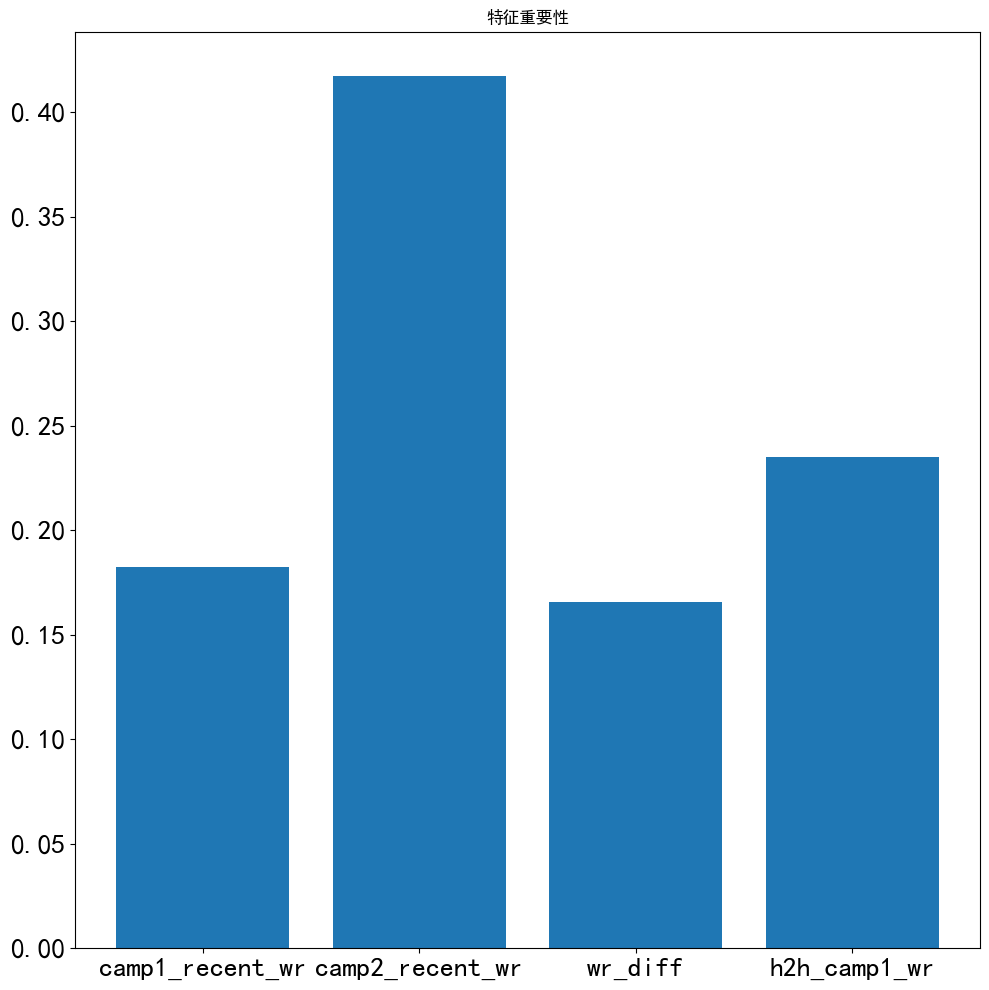

In [119]:
# TODO 5.1：特征重要性图
# 选最佳模型（比如 GBDT 或 RF）
# importances = model.feature_importances_
# 画 barh：横向条形图，特征名做 y 轴
# 保存到 ../reports/figures/E1_特征重要性.png
best_model = models['XGB']
importances = best_model.feature_importances_

plt.figure(figsize=(10,10))
plt.bar(X.columns, importances)
plt.title('特征重要性')
plt.xticks(size=20)
plt.yticks(size=20)
plt.savefig('../reports/figures/E1_特征重要性.png',dpi=300,edgecolor='black',facecolor='white',bbox_inches='tight')
plt.tight_layout()
plt.show()

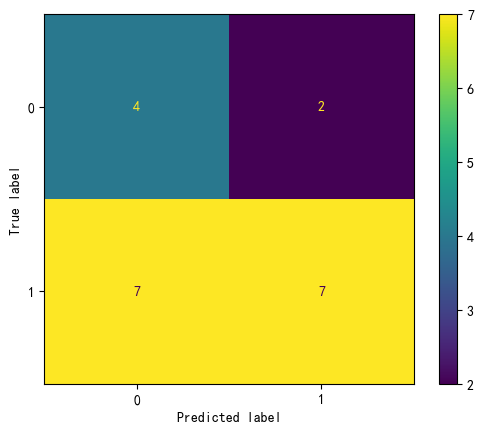

In [120]:
# TODO 5.2 (可选)：混淆矩阵
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# cm = confusion_matrix(y_test, best_model.predict(X_test_s))
# ConfusionMatrixDisplay(cm).plot()
# 保存

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,best_model.predict(X_test_s))

ConfusionMatrixDisplay(cm).plot()


---
## 步骤 6 · 持久化模型

### 思路

模型训练完不保存，下次又得重头跑。用 `joblib` 把模型 + scaler + 特征列表**一起存**——三件套缺一不可：

- 模型：用来预测
- scaler：新数据来了要用同样的标准化参数
- feature_columns：新数据列名/顺序必须跟训练时一致

```python
import joblib
joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'feature_columns': X_train.columns.tolist(),
    'metadata': {
        'auc': 0.72,
        'trained_at': '2026-05-05',
        'train_size': len(X_train),
    },
}, '../output/models/v1_baseline.joblib')
```

> 把元数据一起存的习惯非常关键——半年后回来你不用翻代码就知道这个模型当时啥水平。

In [121]:
# TODO 6.1：保存模型三件套
# 用 joblib 把 dict 整体保存到 ../output/models/v1_baseline.joblib
# 提示：先 mkdir parents=True

import joblib

path = Path("../output/models/").resolve()
if not path.exists():
	path.mkdir(parents=True)

joblib.dump({
	'最佳模型':best_model,
    'scaler': scaler,
    'feature_columns': X_train.columns.tolist(),
    'metadata': {
    'auc': results[results['模型']=='XGB']['AUC'].values[0],
    'trained_at': '2026-05-05',
    'train_size': len(X_train),
}},path/"v1_baseline.joblib")



['D:\\AI数据分析\\项目作品集\\02-KPL实时胜率预测系统\\output\\models\\v1_baseline.joblib']

---
## 📋 总结报告（简历素材）

请按这个模板填，填完直接是简历项目段落的雏形：

```
1. 数据规模
   - 训练集：__79__ 场（____ 至 ____）
   - 测试集：__20__ 场（____ 至 ____）

2. 特征工程
   - 一共 __4__ 个特征
   - 全部来自「赛前可知」信息：___是的___
   - 严格用 shift(1) + rolling 防止数据泄漏

3. 模型对比（按 AUC 排序）
   - ___LR___ : Acc=_0.65_, AUC=_0.51_
   - ___RF___ : Acc=_0.65_, AUC=_0.60_
   - ___GB___ : Acc=_0.55_, AUC=_0.52_
   XGB 0.5  0.56
4. 最佳模型
   - 选择：___RF___
   - 测试集 Accuracy=_0.65, AUC=_0.60_
   - 比 baseline（永远预测多数类）提升 __%  降低

5. 最重要的特征
   - 1: ______（说明业务含义）
   - 2: ______
   - 3: ______

我有一个疑问：为什么这次模型，只用了四个特征呢
我们慢慢爬取了许多字段，哪些都用不上吗？

6. 与旧项目对比
   - 旧项目（D 盘 pythonProject5）Accuracy=95% 但有数据泄漏，不可信
   - 本项目 ____% 但**真实可信**，数据不泄漏，按时间切分

7. V2 改进方向
   - 引入实时数据，按时间切片做"推进式预测"
   - 加入 BP 阵容强度、英雄克制关系
   - ______
```

---
## ✅ 完成自检

- [ ] 特征**全部**来自赛前可知信息（数据泄漏检查通过）
- [ ] 训练集/测试集**按时间**划分，不是随机
- [ ] scaler 只在训练集 fit，测试集只 transform
- [ ] 至少 3 个模型对比，写出 Accuracy + AUC
- [ ] 跟 baseline（永远预测多数类）做了对比
- [ ] 特征重要性图保存到 `reports/figures/`
- [ ] 模型 + scaler + 特征列表 用 joblib 存到 `output/models/`
- [ ] 总结报告 7 项填完

## 🎯 完成后跟我汇报

```
1. 我做了什么：（特征清单 + 模型清单）
2. 我的关键决策（必填，至少 2 条）：
   - 比如：为什么按时间切分而不是随机
   - 比如：为什么不能用 camp1_kill 做特征
3. 模型表现：______
4. 我想确认：______
```

> 做完这个 notebook，**V1 阶段就完成了**——你已经有一个可以放上简历的项目雏形。
> 接下来 V2 阶段会继续升级到「实时预测系统」，但那是后面的故事，先把 V1 做扎实。